In [1]:
import pandas as pd

from sklearn.metrics import silhouette_score
import sklearn as skl

import utils

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load metadata and features
tracks = utils.load('../data/fma_metadata/tracks.csv')
genres = utils.load('../data/fma_metadata/genres.csv')
features = utils.load('../data/fma_metadata/features.csv')
echonest = utils.load('../data/fma_metadata/echonest.csv')

In [3]:
# create genre mapping

def get_top_level_name(genre_id):
    row = genres.loc[genre_id]
    if row['parent'] == 0:  # 0 means top-level
        return row['title']
    return get_top_level_name(row['parent'])

genre_to_root_map = {gid: get_top_level_name(gid) for gid in genres.index}


There are a total of 106574 entries, spanning 16 genres
Full Hierarchical Track Distribution:
             root_title  #tracks
0          Experimental    82674
1                  Rock    80567
2            Electronic    63220
3          Instrumental    28755
4                   Pop    22824
5                  Folk    21338
6               Hip-Hop    12036
7         International    10581
8             Classical     6839
9                  Jazz     6256
10               Spoken     4037
11              Country     3370
12             Soul-RnB     2640
13                Blues     1818
14       Easy Listening     1337
15  Old-Time / Historic      868


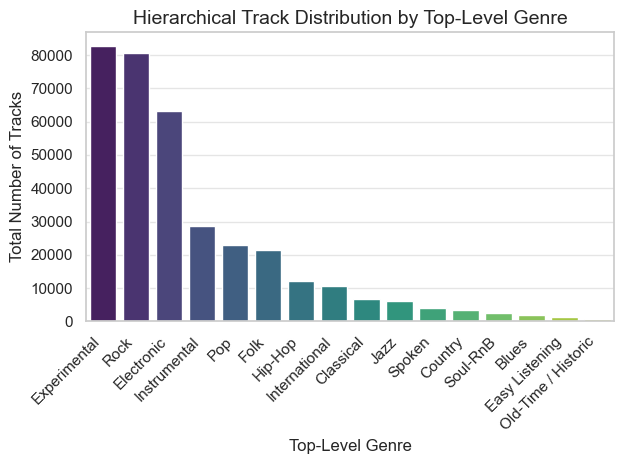

In [5]:
import pandas as pd

genres_df = genres.reset_index()

genres_df['root_title'] = genres_df['genre_id'].apply(get_top_level_name)

full_hierarchy_summary = genres_df.groupby('root_title')['#tracks'].sum().reset_index()

full_hierarchy_summary = full_hierarchy_summary.sort_values(by='#tracks', ascending=False).reset_index(drop=True)

print(f'There are a total of {len(tracks)} entries, spanning {len(full_hierarchy_summary)} genres')
with pd.option_context('display.max_rows', None):
    print("Full Hierarchical Track Distribution:")
    print(full_hierarchy_summary)

sns.set_theme(style="whitegrid")

sns.barplot(
    data=full_hierarchy_summary,
    x='root_title',
    y='#tracks',
    palette='viridis',
    hue='root_title',
)

plt.xticks(rotation=45, ha='right')

plt.xlabel('Top-Level Genre', fontsize=12)
plt.ylabel('Total Number of Tracks', fontsize=12)
plt.title('Hierarchical Track Distribution by Top-Level Genre', fontsize=14)

plt.tight_layout()

plt.savefig('../images/genre_distributions/top_level_distribution.png')


C:\Users\cezar\AppData\Local\Temp\ipykernel_12048\1000797261.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


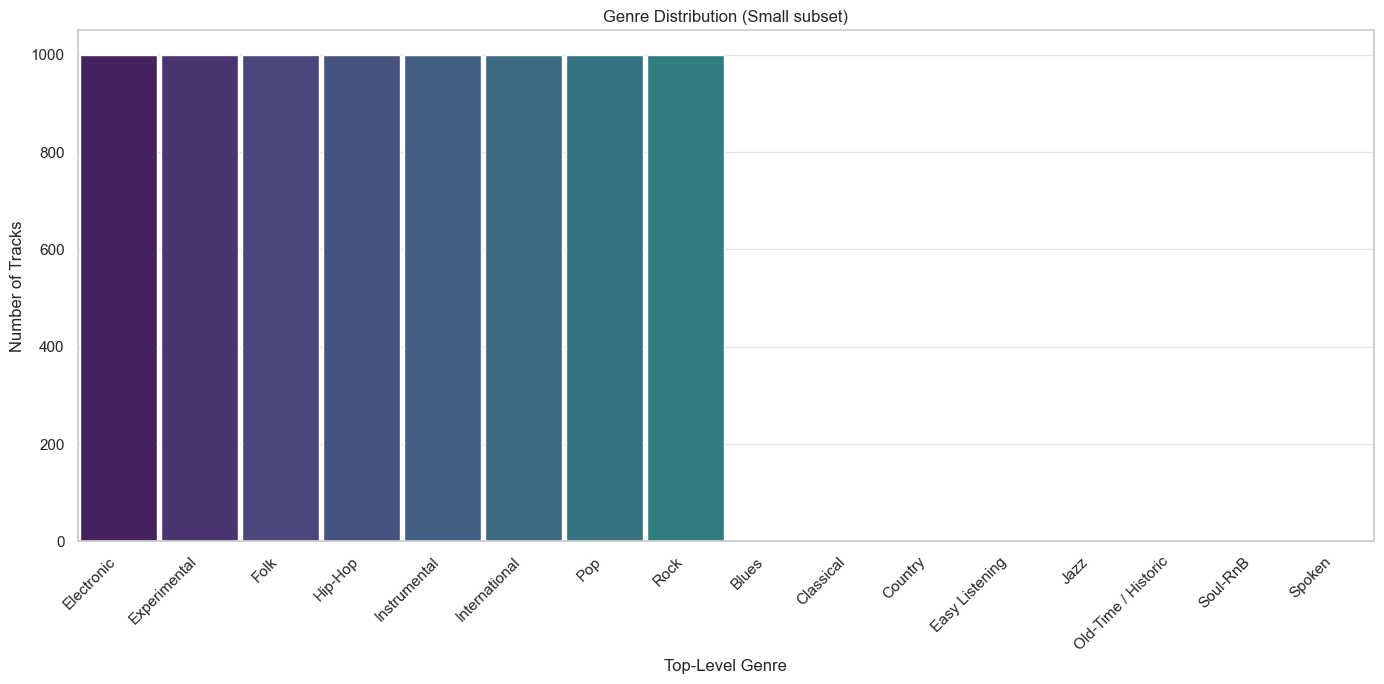

C:\Users\cezar\AppData\Local\Temp\ipykernel_12048\1000797261.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


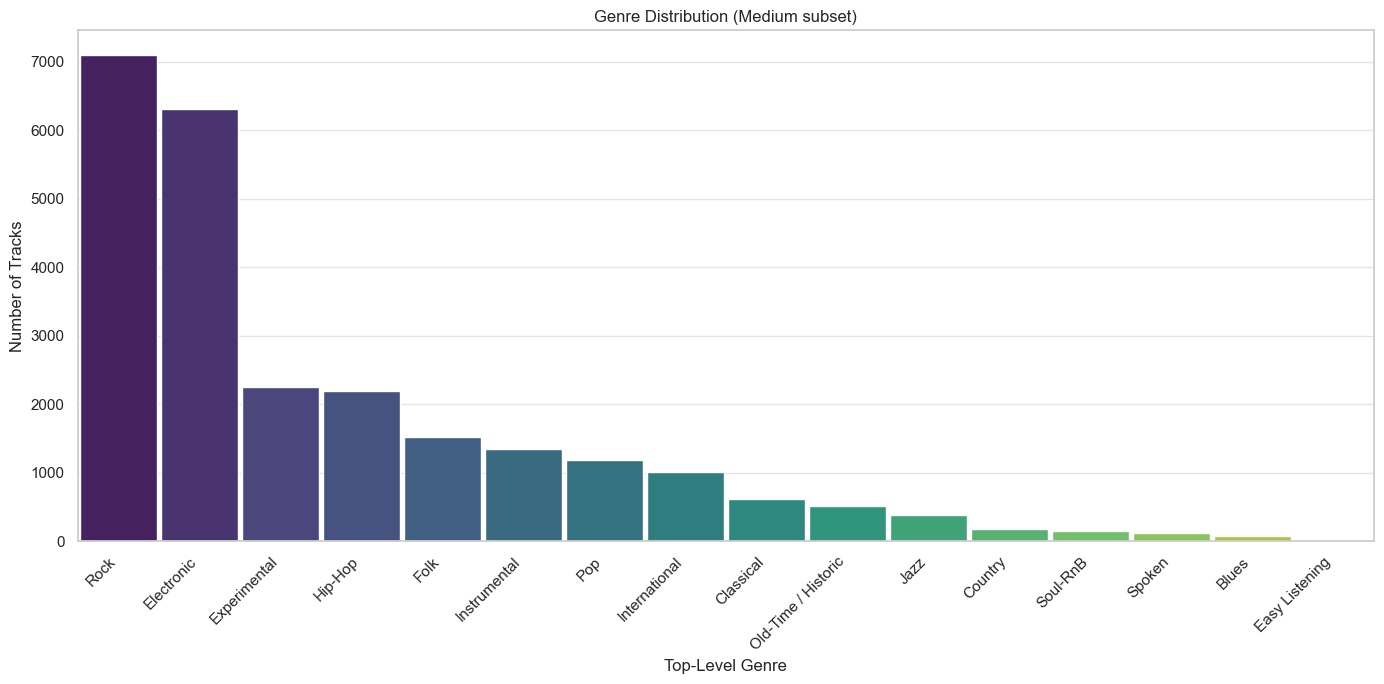

C:\Users\cezar\AppData\Local\Temp\ipykernel_12048\1000797261.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


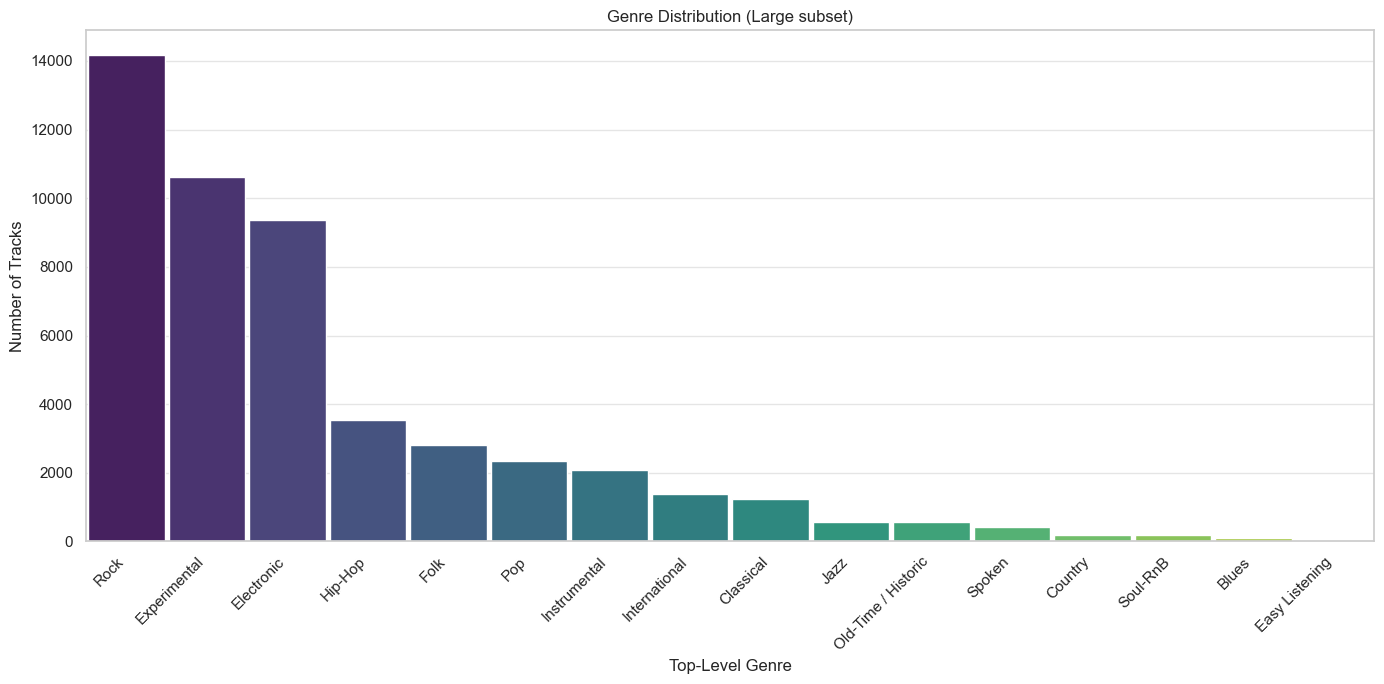

C:\Users\cezar\AppData\Local\Temp\ipykernel_12048\1000797261.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


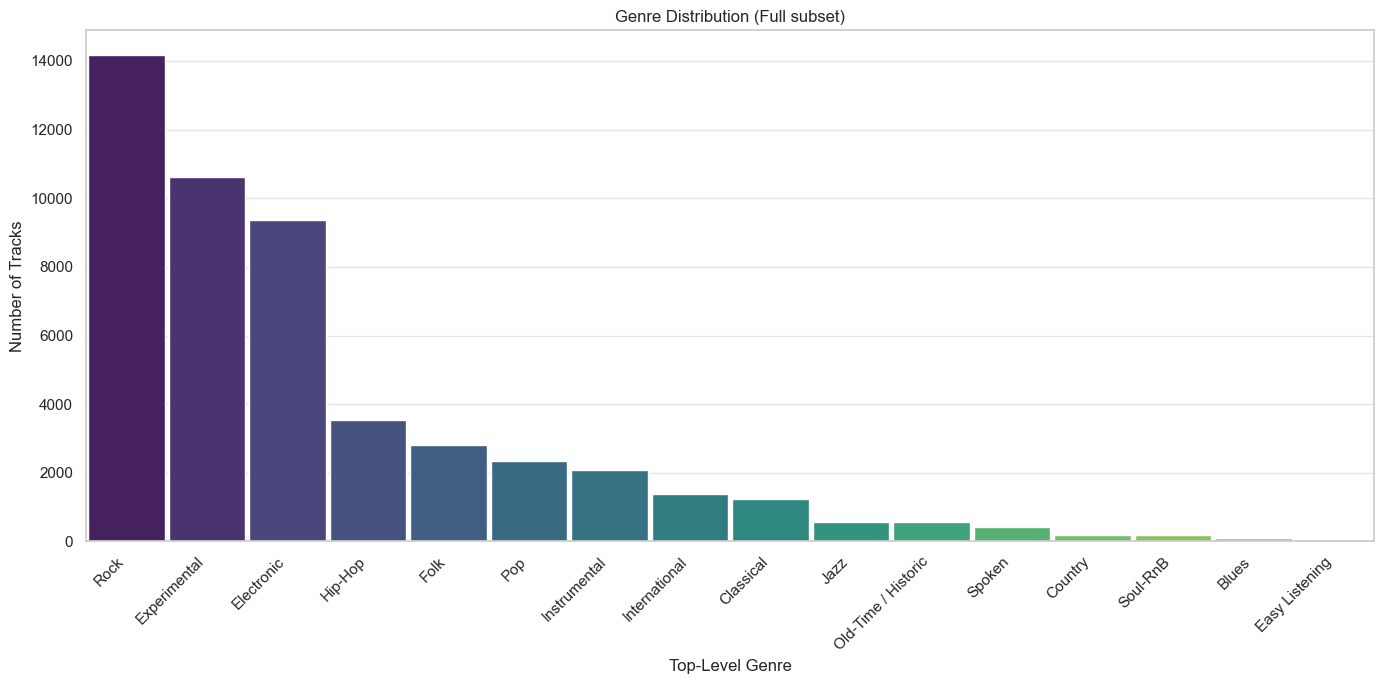

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

subsets = ['small','medium','large','full']
subset_order = ['small','medium','large','full']

sns.set_theme(style="whitegrid")

for subset_name in subsets:

    allowed = subset_order[:subset_order.index(subset_name)+1]

    subset_tracks = tracks[tracks[('set','subset')].isin(allowed)]

    genre_names = subset_tracks[('track','genre_top')]

    subset_summary = (
        genre_names.value_counts()
        .rename_axis('genre')
        .reset_index(name='#tracks')
        .sort_values('#tracks', ascending=False)
    )

    plt.figure(figsize=(14,7))

    order = subset_summary['genre']

    sns.barplot(
        data=subset_summary,
        x='genre',
        y='#tracks',
        palette='viridis',
        width=0.95,
        order=order
    )

    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Top-Level Genre")
    plt.ylabel("Number of Tracks")
    plt.title(f"Genre Distribution ({subset_name.capitalize()} subset)")

    plt.tight_layout()
    #plt.savefig(f"genre_distribution_{subset_name}.png")
    plt.show()

Calculating Silhouette Scores for 11 feature classes...
Processed chroma_cens: 0.0007


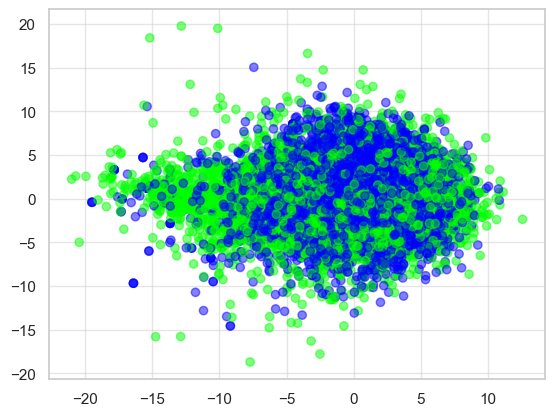

Processed chroma_cqt: 0.0080


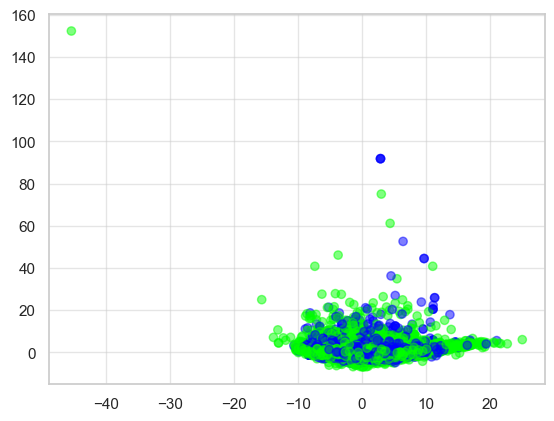

Processed chroma_stft: 0.0362


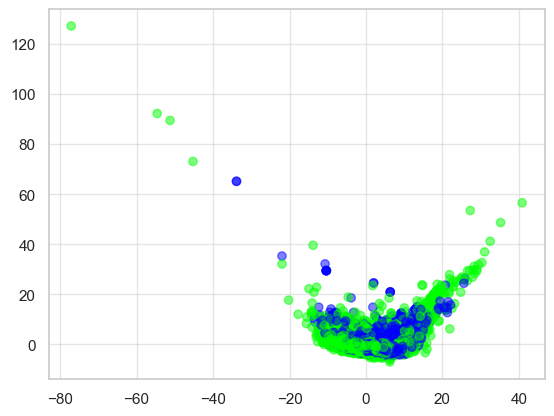

Processed mfcc: 0.0585


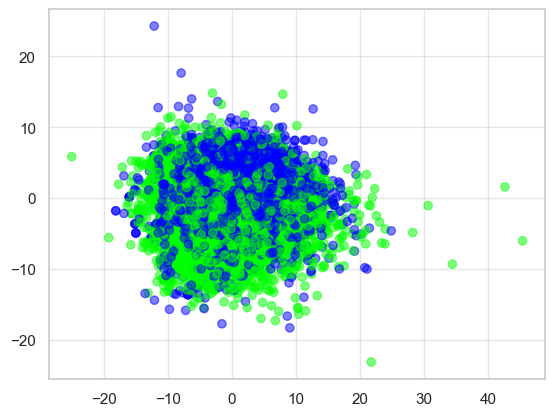

Processed rmse: 0.0748


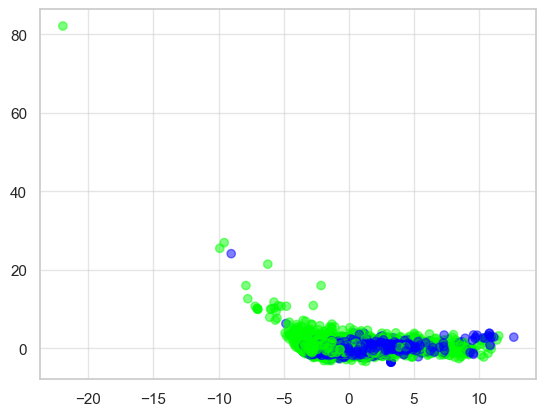

Processed spectral_bandwidth: 0.0484


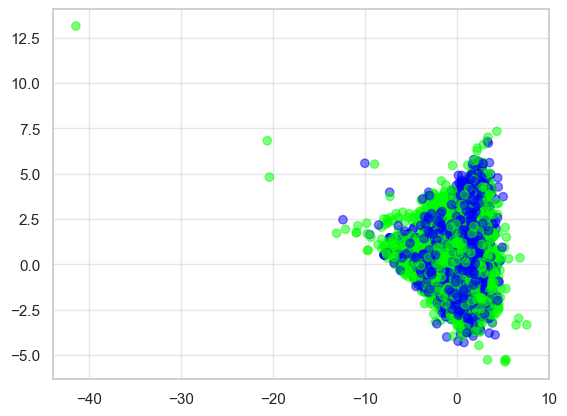

Processed spectral_centroid: 0.0329


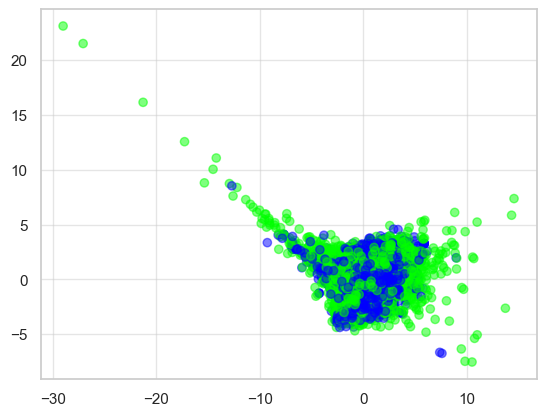

Processed spectral_contrast: 0.0209


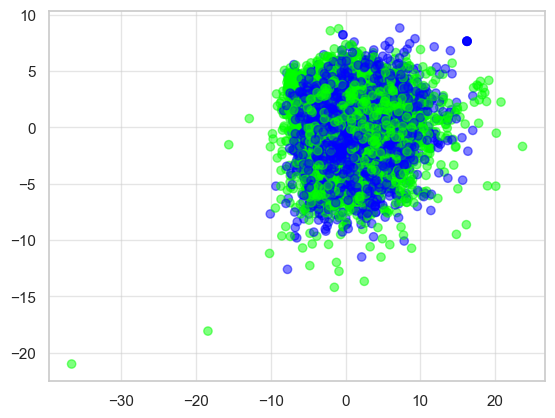

Processed spectral_rolloff: 0.0504


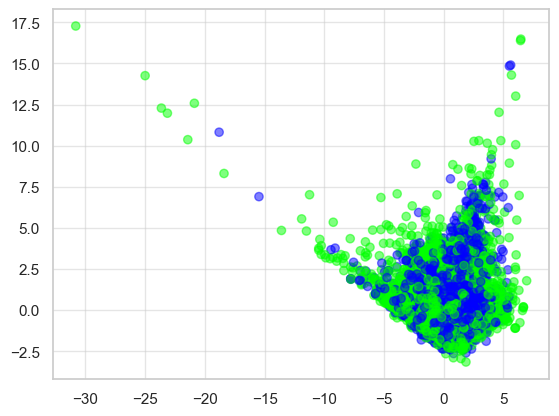

Processed tonnetz: 0.0026


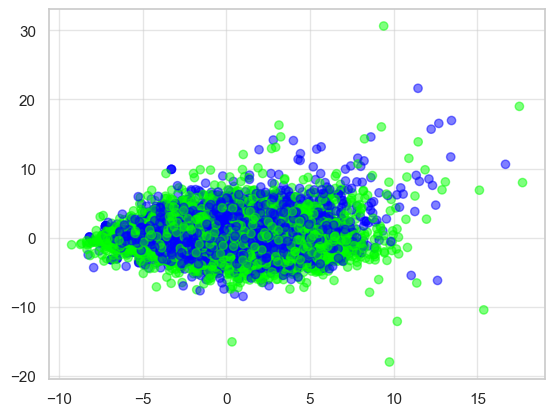

Processed zcr: 0.0025


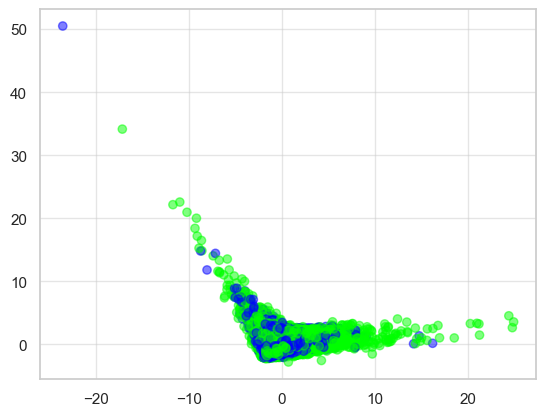

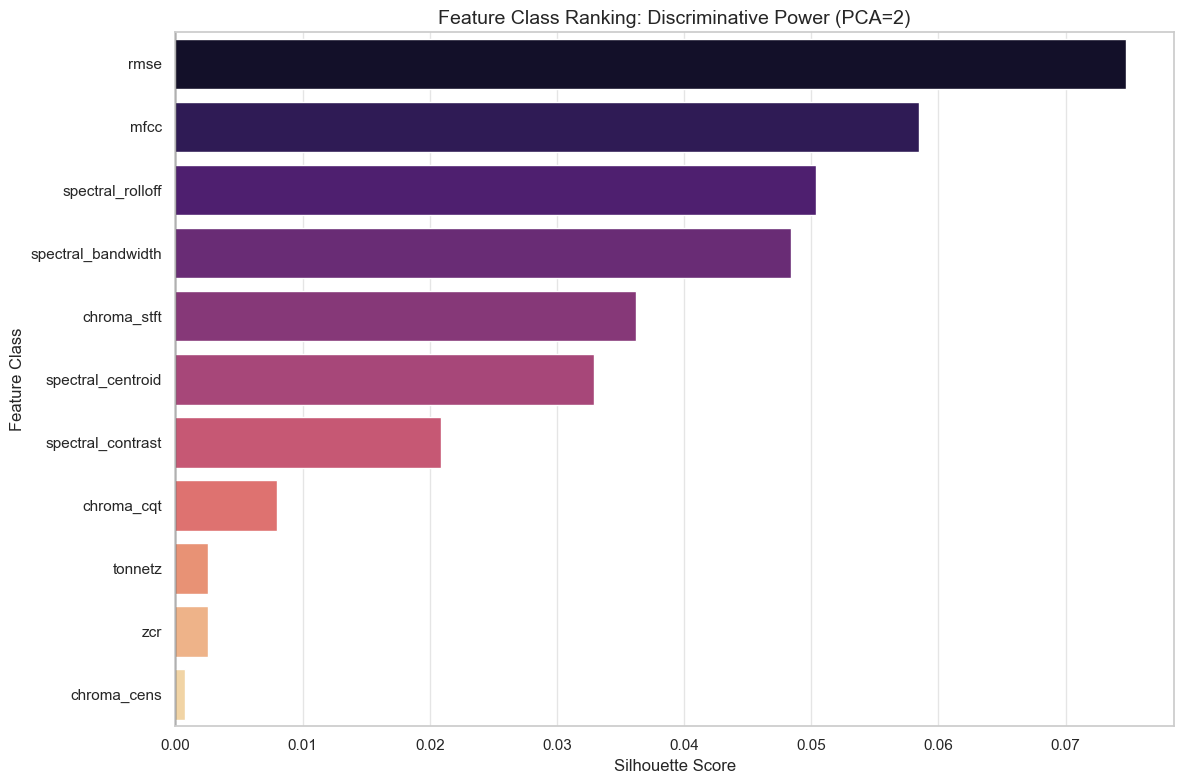


Final Ranking:
     Feature Class  Silhouette Score
              rmse          0.074789
              mfcc          0.058487
  spectral_rolloff          0.050413
spectral_bandwidth          0.048444
       chroma_stft          0.036225
 spectral_centroid          0.032882
 spectral_contrast          0.020873
        chroma_cqt          0.007961
           tonnetz          0.002581
               zcr          0.002539
       chroma_cens          0.000725


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score

target_genres = ['Experimental', 'Electronic']
subset_mask = tracks['track', 'genre_top'].isin(target_genres)

y_raw = tracks.loc[subset_mask, ('track', 'genre_top')]
le = LabelEncoder()
y = le.fit_transform(y_raw)

feature_classes = features.columns.levels[0]

results = []

print(f"Calculating Silhouette Scores for {len(feature_classes)} feature classes...")

for f_class in feature_classes:
    try:
        X_raw = features.loc[subset_mask, f_class]

        X_scaled = StandardScaler().fit_transform(X_raw)

        X_pca = PCA(n_components=2).fit_transform(X_scaled)

        score = silhouette_score(X_pca, y)

        results.append({
            'Feature Class': f_class,
            'Silhouette Score': score
        })
        print(f"Processed {f_class}: {score:.4f}")
        plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='brg', alpha=0.5)
        plt.show()

    except Exception as e:
        print(f"Skipping {f_class}: {e}")

ranking_df = pd.DataFrame(results).sort_values(by='Silhouette Score', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=ranking_df, x='Silhouette Score', y='Feature Class', palette='magma', hue='Feature Class', legend=False)
plt.title('Feature Class Ranking: Discriminative Power (PCA=2)', fontsize=14)
plt.axvline(0, color='black', lw=1) # Reference line
plt.tight_layout()
plt.show()

print("\nFinal Ranking:")
print(ranking_df.to_string(index=False))

In [6]:
genres_df = genres.reset_index()
genres_df['root_name'] = genres_df['genre_id'].apply(get_top_level_name)

genre_specific_dist = genres_df[['root_name', 'title', '#tracks']].sort_values(
    by=['root_name', '#tracks'], ascending=[True, False]
)

with pd.option_context('display.max_rows', None):
    print(genre_specific_dist)

               root_name                     title  #tracks
2                  Blues                     Blues     1752
144                Blues                    Gospel       66
4              Classical                 Classical     4106
149            Classical    Contemporary Classical     1239
112            Classical            Composed Music      630
96             Classical    20th Century Classical      292
129            Classical              Choral Music      216
128            Classical             Chamber Music      170
127            Classical                     Opera      161
130            Classical                  Symphony       25
8                Country                   Country     1987
74               Country                 Americana      994
41               Country                 Bluegrass      178
78               Country                Rockabilly      128
148              Country         Country & Western       79
135              Country             Wes

Generating distribution charts for 16 genres...
Chart for International genre distribution.


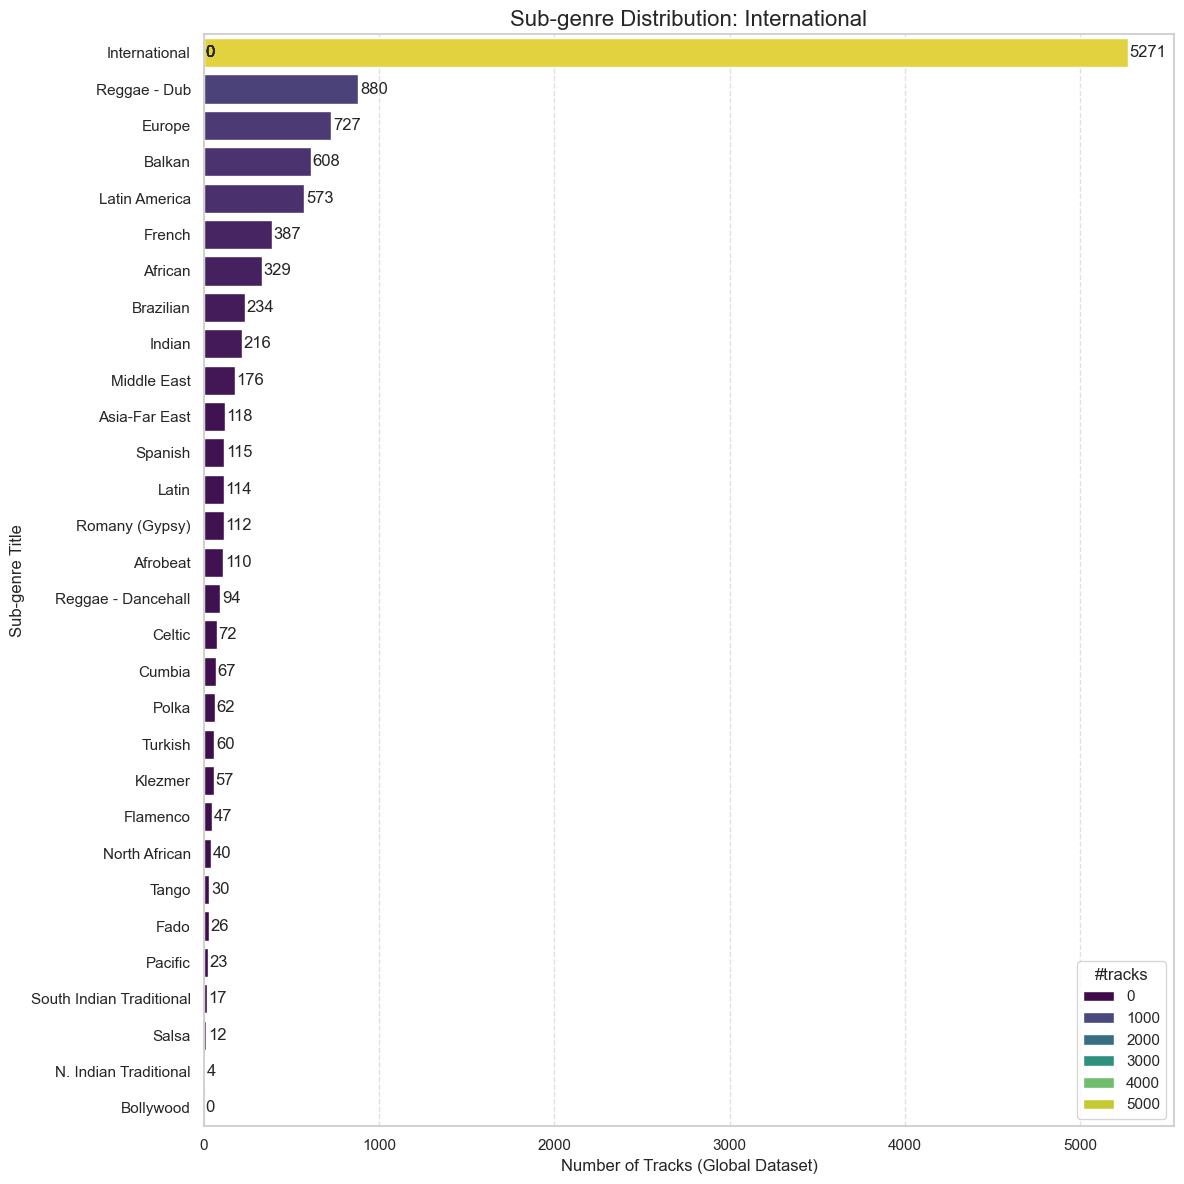

Chart for Blues genre distribution.


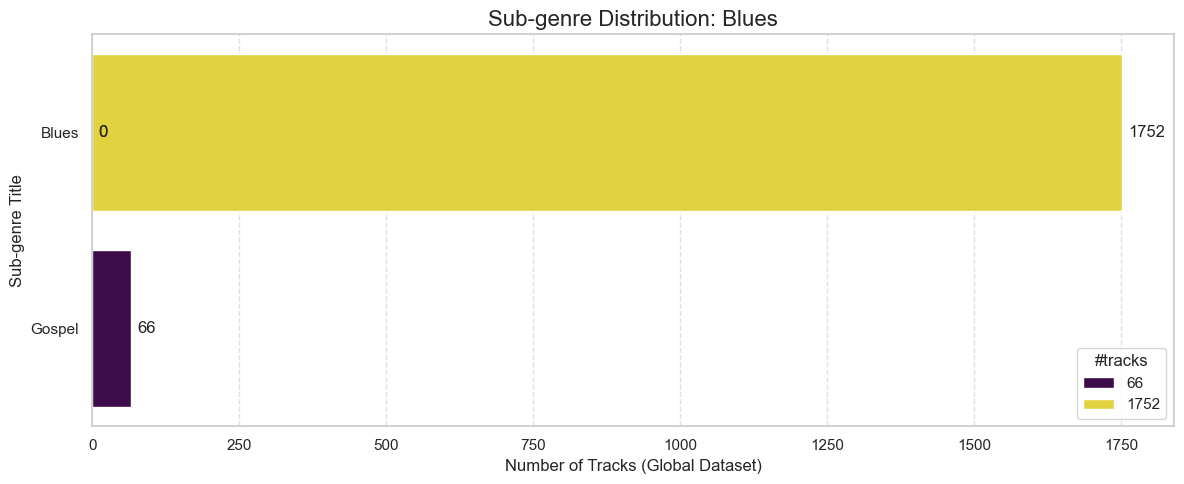

Chart for Jazz genre distribution.


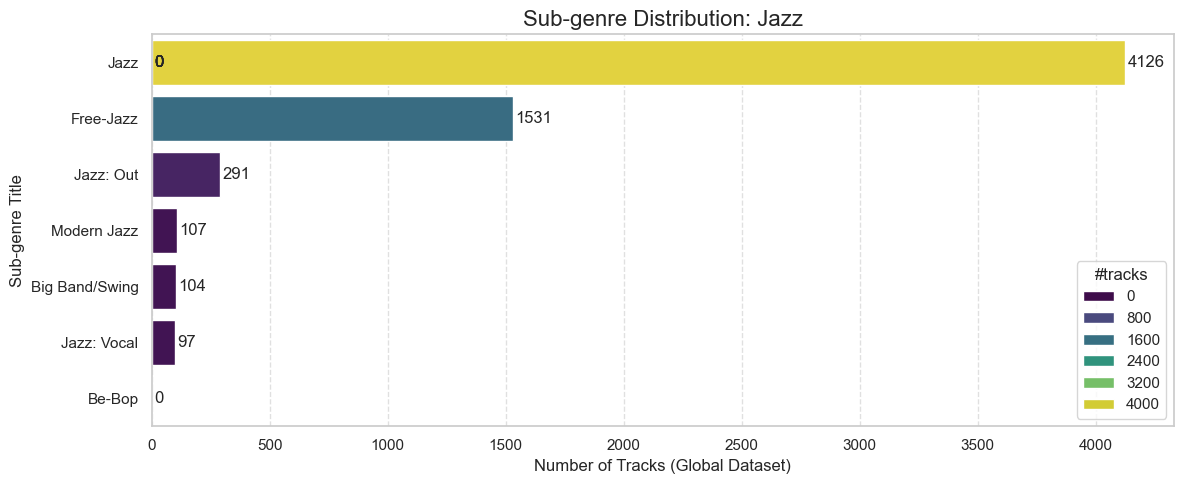

Chart for Classical genre distribution.


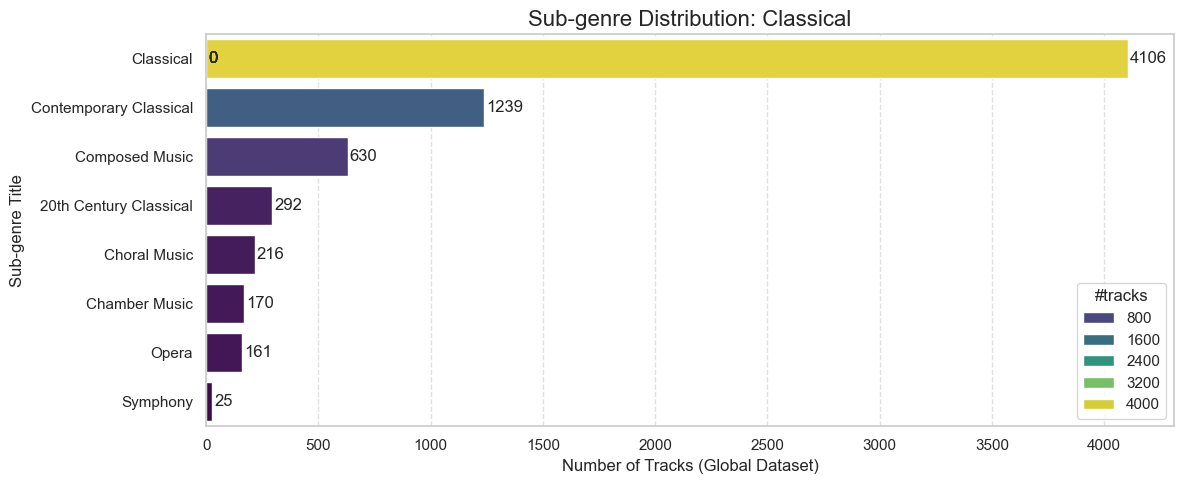

Chart for Country genre distribution.


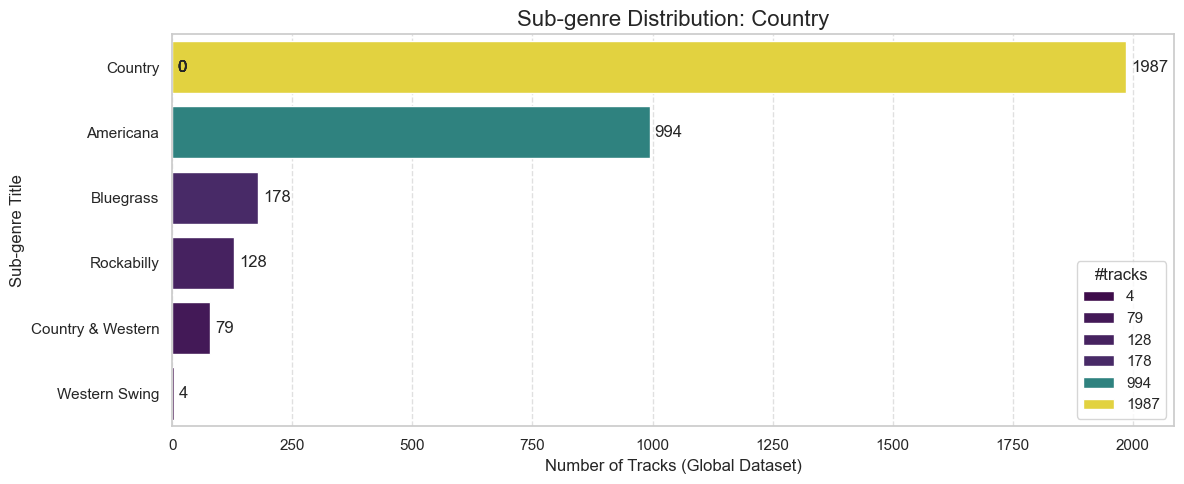

Chart for Pop genre distribution.


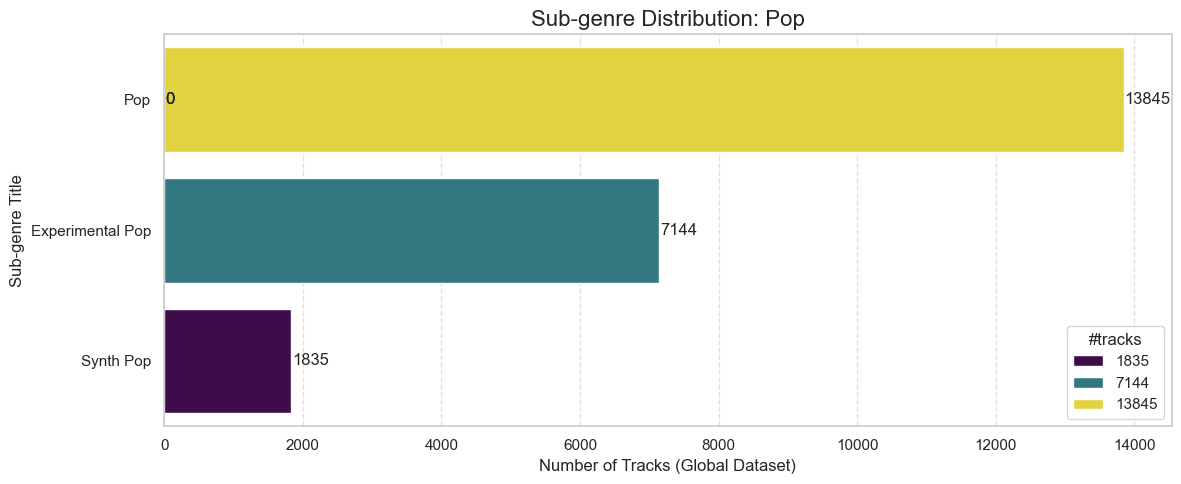

Chart for Rock genre distribution.


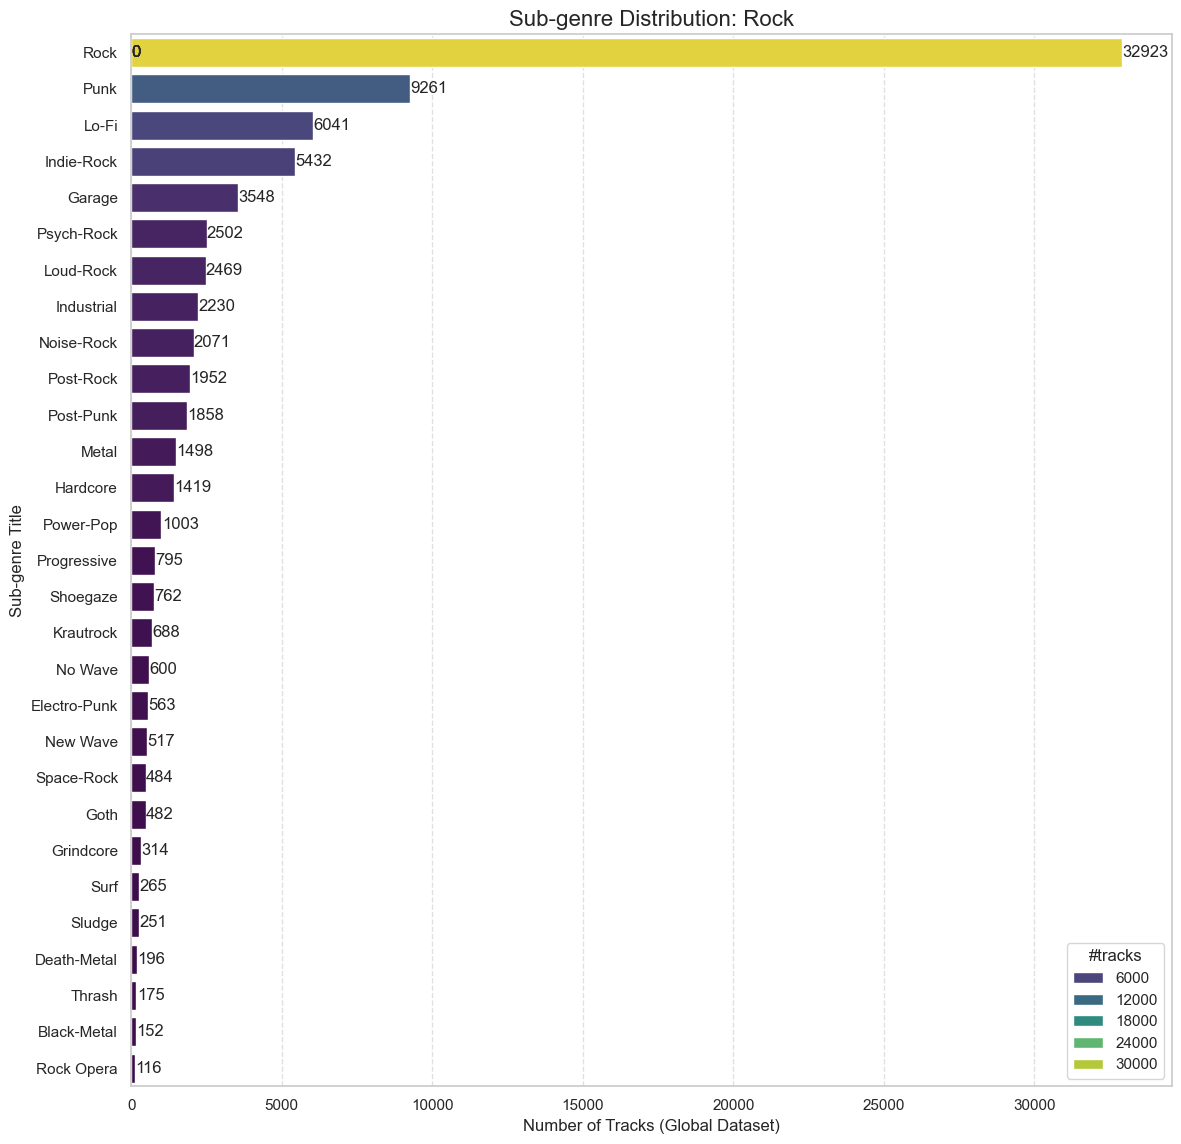

Chart for Easy Listening genre distribution.


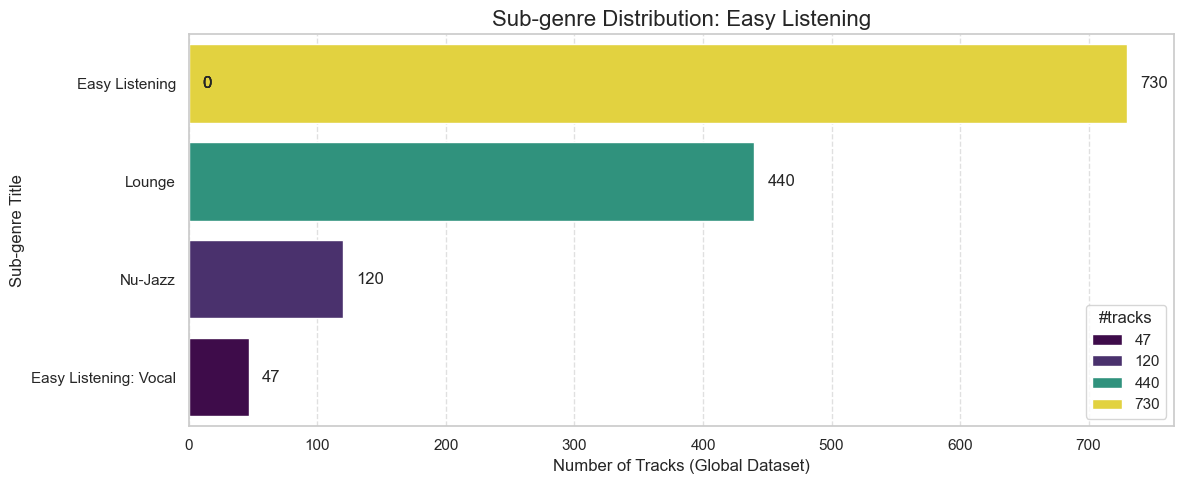

Chart for Soul-RnB genre distribution.


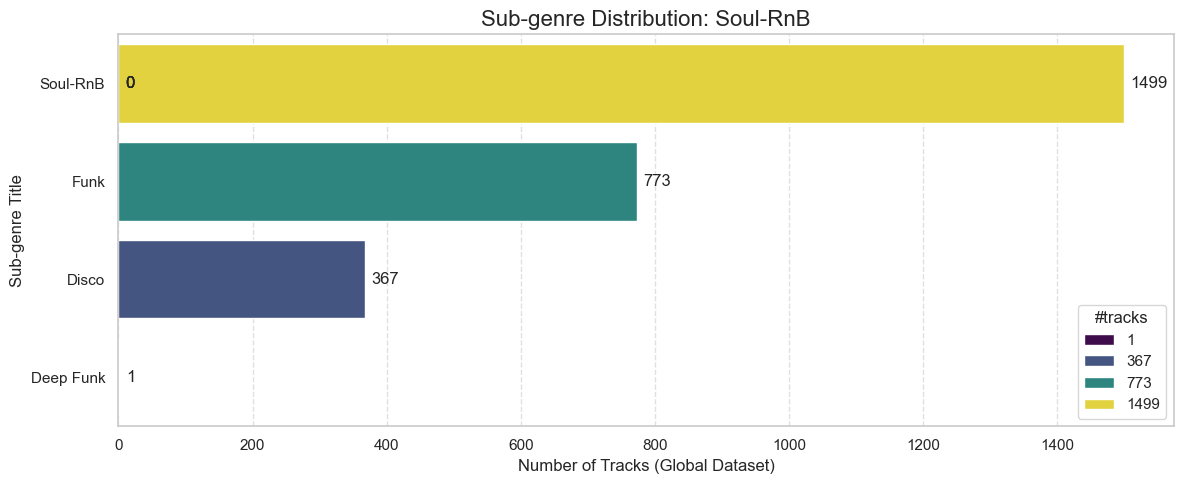

Chart for Electronic genre distribution.


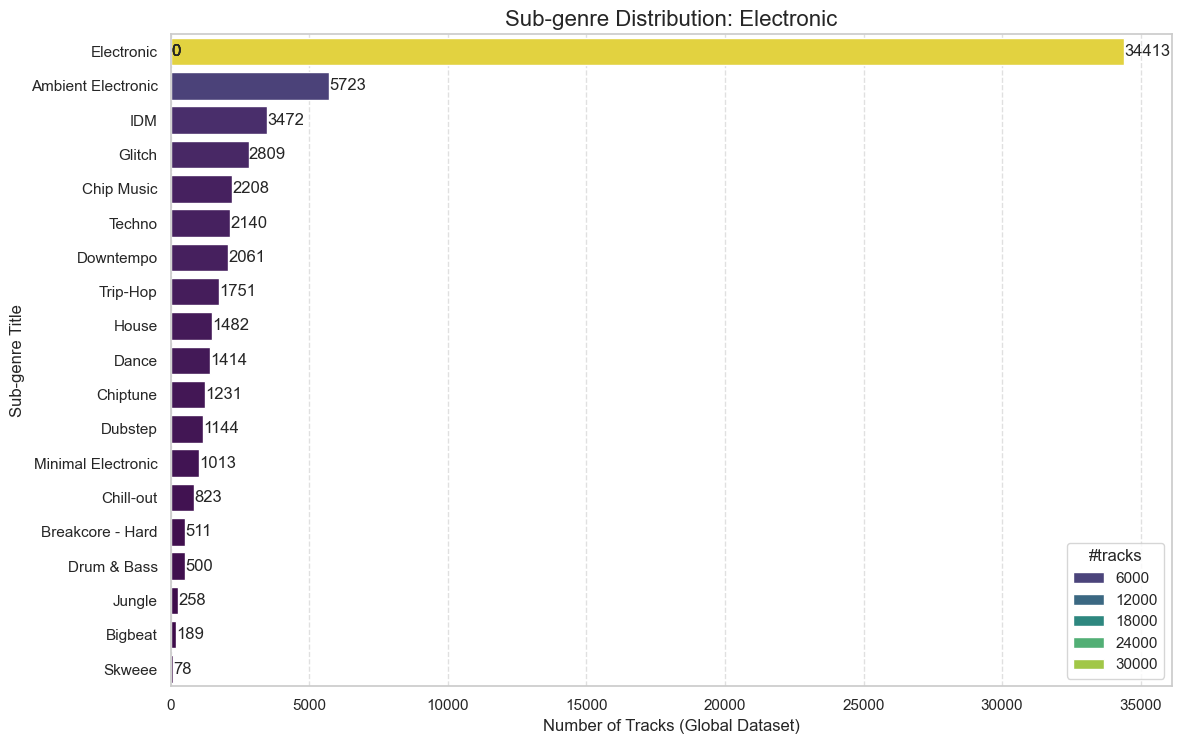

Chart for Folk genre distribution.


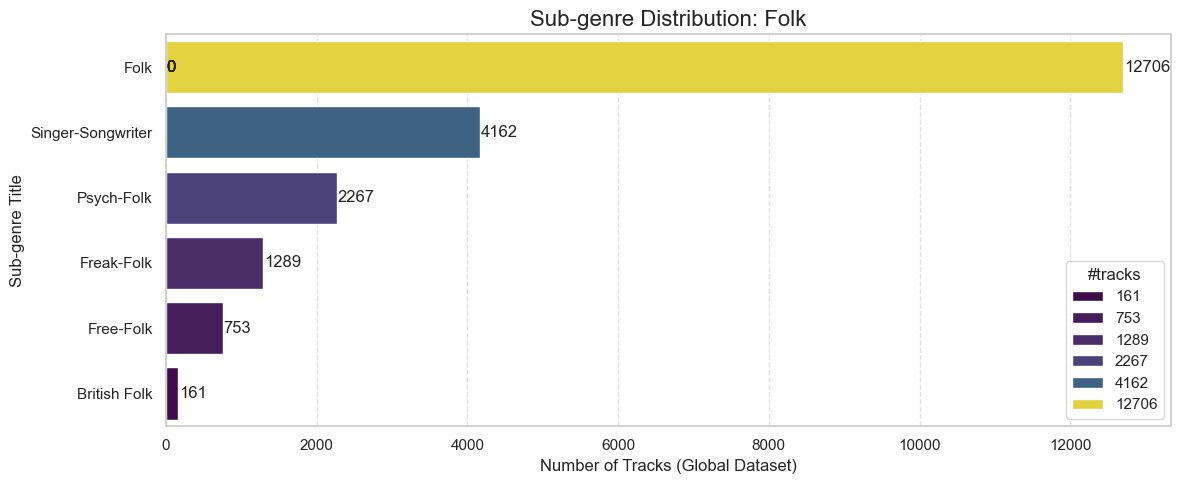

Chart for Spoken genre distribution.


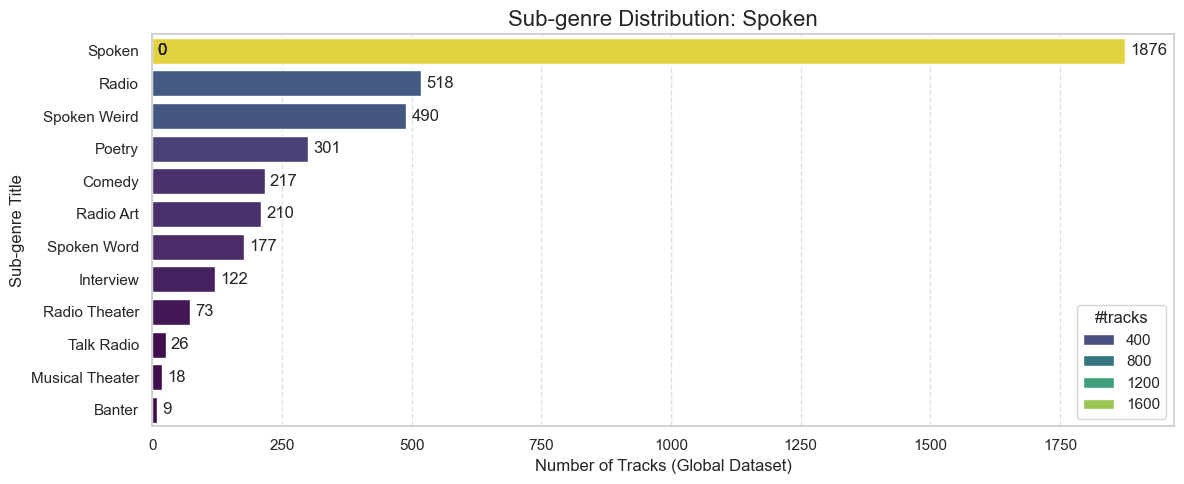

Chart for Hip-Hop genre distribution.


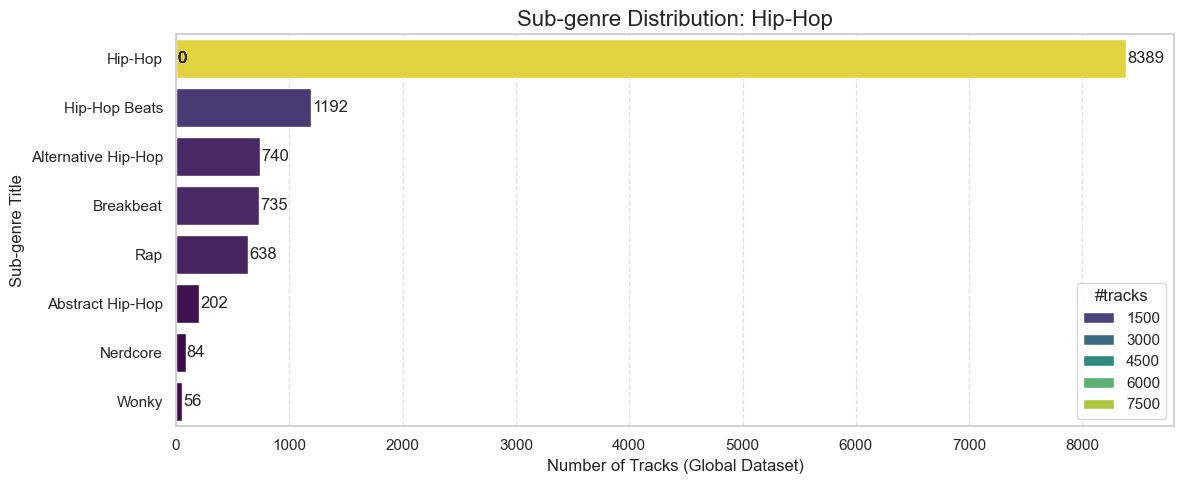

Chart for Experimental genre distribution.


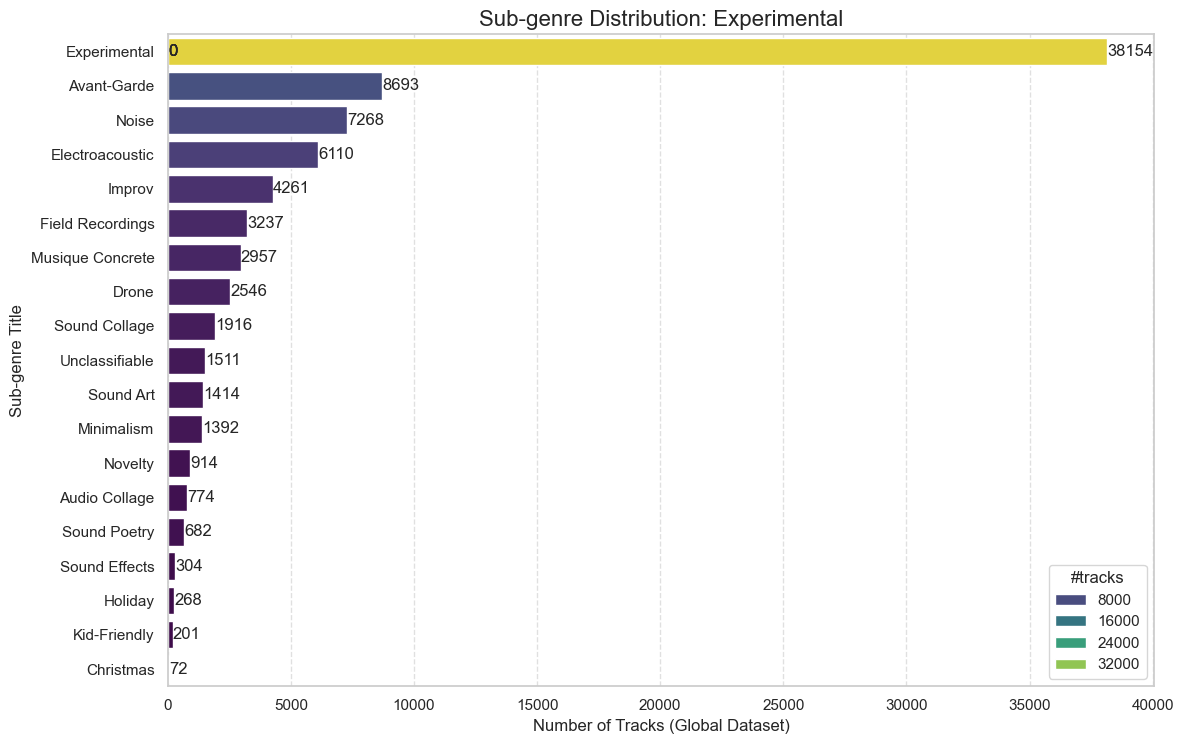

Chart for Instrumental genre distribution.


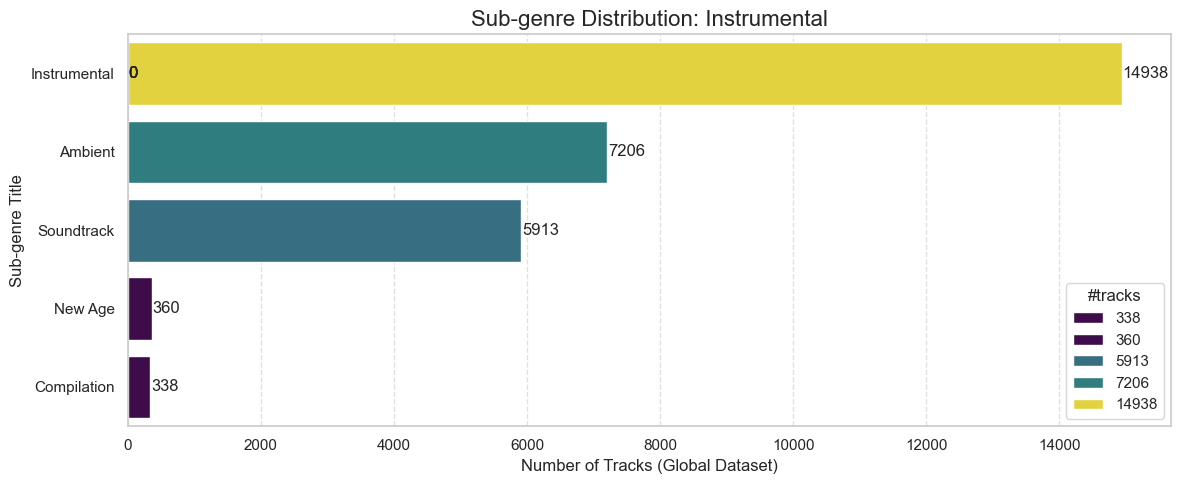

All charts saved to 'images/genre_distributions/'


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../images/genre_distributions', exist_ok=True)

genres_df = genres.copy()
genres_df['root_name'] = [get_top_level_name(gid) for gid in genres_df.index]

top_level_roots = genres_df[genres_df['parent'] == 0]['title'].unique()

print(f"Generating distribution charts for {len(top_level_roots)} genres...")

for root in top_level_roots:
    sub_data = genres_df[genres_df['root_name'] == root].sort_values(by='#tracks', ascending=False)

    if len(sub_data) <= 1:
        continue

    plt.figure(figsize=(12, max(5, len(sub_data) * 0.4)))

    sns.barplot(data=sub_data, x='#tracks', y='title', palette='viridis', hue='#tracks')

    for i, p in enumerate(plt.gca().patches):
        width = p.get_width()
        plt.gca().text(width + 10, p.get_y() + p.get_height()/2,
                       f'{int(width)}', va='center')

    plt.title(f'Sub-genre Distribution: {root}', fontsize=16)
    plt.xlabel('Number of Tracks (Global Dataset)', fontsize=12)
    plt.ylabel('Sub-genre Title', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()

    print(f'Chart for {root} genre distribution.')
    plt.show()

    safe_name = root.replace(' ', '_').replace('/', '_')
    plt.savefig(f'images/genre_distributions/{safe_name}_dist.png')
    plt.close()

print("All charts saved to 'images/genre_distributions/'")

In [10]:
genres_util = utils.Genres(genres)

root_ids = genres_util.find_roots()

import os
os.makedirs('../images/genre_trees', exist_ok=True)

print(f"Generating trees for {len(root_ids)} top-level genres...")

for root_id in root_ids:
    root_title = genres.loc[root_id, 'title'].replace(' ', '_').replace('/', '_')

    graph = genres_util.create_tree(root_id, depth=None)

    output_path = f'images/genre_trees/{root_title}_tree.png'
    graph.write_png(output_path)

    print(f"Saved tree for: {root_title} to {output_path}")

Generating trees for 16 top-level genres...
Saved tree for: International to images/genre_trees/International_tree.png
Saved tree for: Blues to images/genre_trees/Blues_tree.png
Saved tree for: Jazz to images/genre_trees/Jazz_tree.png
Saved tree for: Classical to images/genre_trees/Classical_tree.png
Saved tree for: Old-Time___Historic to images/genre_trees/Old-Time___Historic_tree.png
Saved tree for: Country to images/genre_trees/Country_tree.png
Saved tree for: Pop to images/genre_trees/Pop_tree.png
Saved tree for: Rock to images/genre_trees/Rock_tree.png
Saved tree for: Easy_Listening to images/genre_trees/Easy_Listening_tree.png
Saved tree for: Soul-RnB to images/genre_trees/Soul-RnB_tree.png
Saved tree for: Electronic to images/genre_trees/Electronic_tree.png
Saved tree for: Folk to images/genre_trees/Folk_tree.png
Saved tree for: Spoken to images/genre_trees/Spoken_tree.png
Saved tree for: Hip-Hop to images/genre_trees/Hip-Hop_tree.png
Saved tree for: Experimental to images/genre